In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df1 = pd.read_excel("../data/raw/online_retail/online_retail_II.xlsx", sheet_name="Year 2009-2010")
df2 = pd.read_excel("../data/raw/online_retail/online_retail_II.xlsx", sheet_name="Year 2010-2011")

print("Sheet 1 shape:", df1.shape)
print("Sheet 2 shape:", df2.shape)

df = pd.concat([df1, df2], ignore_index=True)
print("Combined shape:", df.shape)
print("\nColumns:", df.columns.tolist())


Sheet 1 shape: (525461, 8)
Sheet 2 shape: (541910, 8)
Combined shape: (1067371, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [2]:
print(df.head(5))
print("\nDtypes:\n", df.dtypes)


  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

Dtypes:
 Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64

In [3]:
print("Missing values:")
print(df.isnull().sum())
print("\nMissing % :")
print((df.isnull().sum() / len(df) * 100).round(2))


Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Missing % :
Invoice         0.00
StockCode       0.00
Description     0.41
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    22.77
Country         0.00
dtype: float64


In [4]:
print("Negative quantities:", (df["Quantity"] < 0).sum())
print("Zero quantities:", (df["Quantity"] == 0).sum())
print("Negative prices:", (df["Price"] < 0).sum())
print("Zero prices:", (df["Price"] == 0).sum())

print("\nCancelled orders (Invoice starts with C):", df["Invoice"].astype(str).str.startswith("C").sum())
print("\nUnique StockCodes:", df["StockCode"].nunique())

# Non-product stock codes (manual adjustments, postage, etc.)
non_product = df[~df["StockCode"].astype(str).str.match(r"^\d{5}")]["StockCode"].value_counts().head(15)
print("\nNon-product StockCodes:\n", non_product)


Negative quantities: 22950
Zero quantities: 0
Negative prices: 5
Zero prices: 6202

Cancelled orders (Invoice starts with C): 19494

Unique StockCodes: 5305

Non-product StockCodes:
 StockCode
POST            2122
DOT             1446
M               1421
C2               282
D                177
S                104
BANK CHARGES     102
ADJUST            67
AMAZONFEE         43
DCGS0058          31
gift_0001_20      29
gift_0001_30      29
DCGSSGIRL         25
DCGSSBOY          23
PADS              19
Name: count, dtype: int64


In [5]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print("Date range:", df["InvoiceDate"].min(), "→", df["InvoiceDate"].max())
print("Unique customers:", df["Customer ID"].nunique())
print("Unique countries:", df["Country"].nunique())
print("\nTop countries by orders:")
print(df["Country"].value_counts().head(10))


Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Unique customers: 5942
Unique countries: 43

Top countries by orders:
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64


Revenue stats (clean rows only):
count    1.041671e+06
mean     2.013397e+01
std      2.031167e+02
min      1.000000e-03
25%      3.900000e+00
50%      9.960000e+00
75%      1.770000e+01
max      1.684696e+05
Name: Revenue, dtype: float64


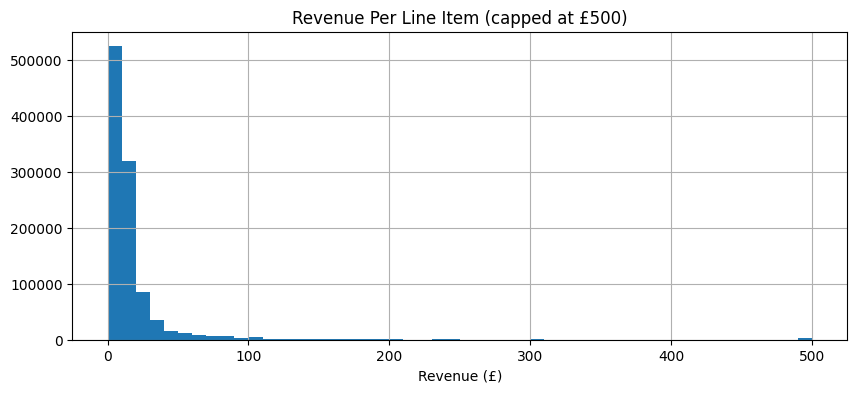

In [6]:
df["Revenue"] = df["Quantity"] * df["Price"]
clean = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
print("Revenue stats (clean rows only):")
print(clean["Revenue"].describe())

plt.figure(figsize=(10, 4))
clean["Revenue"].clip(upper=500).hist(bins=50)
plt.title("Revenue Per Line Item (capped at £500)")
plt.xlabel("Revenue (£)")
plt.show()


In [7]:
# Estimate clean row count
mask = (
    df["Customer ID"].notna() &
    df["Quantity"] > 0 &
    (df["Price"] > 0) &
    (~df["Invoice"].astype(str).str.startswith("C")) &
    (df["StockCode"].astype(str).str.match(r"^\d{5}")) &
    df["Description"].notna()
)
print(f"Rows before cleaning: {len(df):,}")
print(f"Rows after cleaning:  {mask.sum():,}")
print(f"Rows dropped:         {(~mask).sum():,} ({(~mask).mean()*100:.1f}%)")

print("""
ONLINE RETAIL II EDA SUMMARY
=============================
- 1,067,371 raw rows (2 years, UK retailer)
- 22.77% missing Customer ID → drop
- 22,950 returns (negative qty) → drop
- 6,202 zero-price rows → drop
- 19,494 cancelled invoices → drop
- Non-product codes (POST, DOT, BANK CHARGES) → drop
- ~30% rows will be dropped — expected for this dataset

CLEANING PLAN:
- Drop missing Customer ID
- Drop negative/zero Quantity
- Drop negative/zero Price
- Drop invoices starting with 'C' (cancellations)
- Keep only numeric 5-digit StockCodes
- Drop missing Description
- Add revenue = Quantity × Price
- Rename columns to snake_case
- Save for Kafka producer simulation
""")


Rows before cleaning: 1,067,371
Rows after cleaning:  255,246
Rows dropped:         812,125 (76.1%)

ONLINE RETAIL II EDA SUMMARY
- 1,067,371 raw rows (2 years, UK retailer)
- 22.77% missing Customer ID → drop
- 22,950 returns (negative qty) → drop
- 6,202 zero-price rows → drop
- 19,494 cancelled invoices → drop
- Non-product codes (POST, DOT, BANK CHARGES) → drop
- ~30% rows will be dropped — expected for this dataset

CLEANING PLAN:
- Drop missing Customer ID
- Drop negative/zero Quantity
- Drop negative/zero Price
- Drop invoices starting with 'C' (cancellations)
- Keep only numeric 5-digit StockCodes
- Drop missing Description
- Add revenue = Quantity × Price
- Rename columns to snake_case
- Save for Kafka producer simulation

